### **Code Tugas Besar Kelompok 12 : Clustering DBSCAN Kepadatan Rumah Ibadah Lampung Selatan**
---
> Kelompok 12 : \
1. Arafi Ramadhan Maulana 122450002
2. Elok Fiola 			  122450051
3. Alvia Asrinda Br.Ginting   122450077
4. Kayla Amanda Sukma       122450086
5. Marleta Cornelia Leander 122450092
6. M. Deriansyah Okutra       122450101
7.  Ferdy Kevin Naibaho        122450107

---

Import Library

In [68]:
import folium
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from geopy.distance import great_circle
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

#Memuat Peta Bandar Lampung

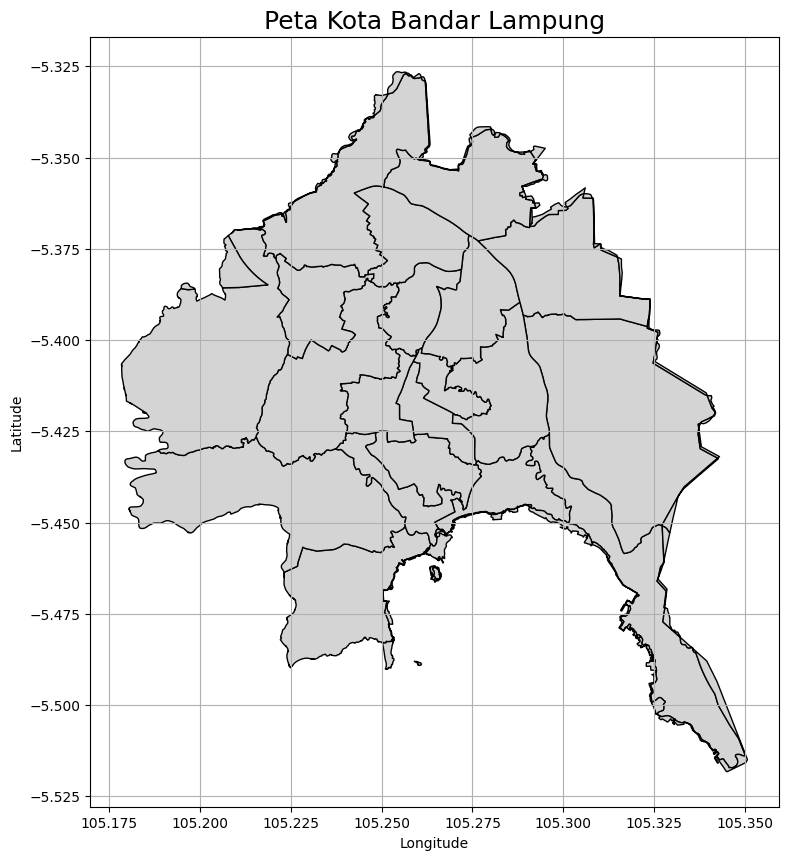

In [69]:

shapefile = "/content/gabungan_kecamatan_wilayah.shp" 
gdf_boundary = gpd.read_file(shapefile)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_boundary.plot(ax=ax, color='#D4D4D4', edgecolor='black')

plt.title('Peta Kota Bandar Lampung', fontsize=18)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

#Melihat Peta Persebaran secara menyeluruh

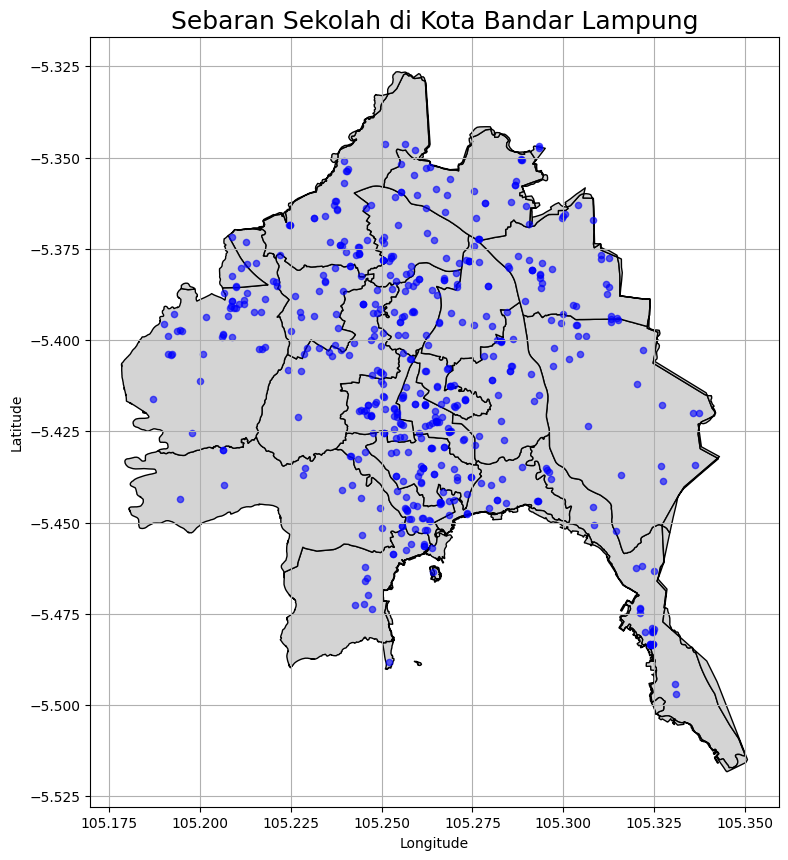

In [70]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

shapefile = "/content/gabungan_kecamatan_wilayah.shp" 
gdf_boundary = gpd.read_file(shapefile)

csv_path = "/content/Data Sekolah.csv"
df_sekolah = pd.read_csv(csv_path)

df_sekolah = df_sekolah.rename(columns={'Y': 'Latitude', 'Z': 'Longitude'})

geometry = [Point(xy) for xy in zip(df_sekolah['Longitude'], df_sekolah['Latitude'])]
gdf_sekolah = gpd.GeoDataFrame(df_sekolah, crs='EPSG:4326', geometry=geometry)

def add_image(ax, image_path, zoom=1, x=0.9, y=0.9):
    img = plt.imread(image_path)
    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(imagebox, (x, y), frameon=False, xycoords='axes fraction')
    ax.add_artist(ab)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_boundary.plot(ax=ax, color='#D4D4D4', edgecolor='black')
gdf_sekolah.plot(ax=ax, color='blue', markersize=20, alpha=0.6)

plt.title('Sebaran Sekolah di Kota Bandar Lampung', fontsize=18)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()


In [71]:
df_sekolah.head()

,NAMA SEKOLAH,Latitude,Longitude
0,SDN 1 BERINGIN RAYA,-5.398338,105.206212
1,SDN 1 PINANG JAYA,-5.397419,105.194957
2,SDN 1 SUMBER AGUNG,-5.416216,105.187091
3,SDN 1 SUMBEREJO,-5.392346,105.214923
4,SDN 2 BERINGIN RAYA,-5.399244,105.206185


# Penentuan Parameter DBSCAN

- **MinPts** ditentukan menggunakan rumus `ln(n)` di mana `n` adalah jumlah total titik/sekolah.  
  Untuk dataset ini (jumlah sekolah = 512), diperoleh:
  

MinPts yang dihitung dari ln(n): 6


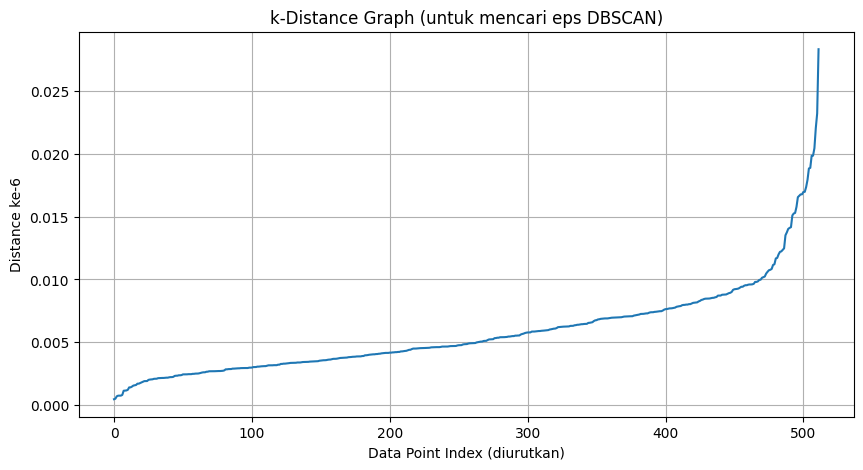

In [72]:
import numpy as np

n = len(df_sekolah) 
min_pts = int(np.log(n))
print(f"MinPts yang dihitung dari ln(n): {min_pts}")
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

coords = df[['Longitude', 'Latitude']].values

neigh = NearestNeighbors(n_neighbors=min_pts)
nbrs = neigh.fit(coords)
distances, indices = nbrs.kneighbors(coords)

k_distances = np.sort(distances[:, -1]) 

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel("Data Point Index (diurutkan)")
plt.ylabel(f"Distance ke-{min_pts}")
plt.title("k-Distance Graph (untuk mencari eps DBSCAN)")
plt.grid(True)
plt.show()


Menggunakan rumus ln(n) untuk penentuan MinPts yaitu 6, sehingga dicari nilai eps Menggunakan KNN untuk mencari k tetangga terdekat dari setiap titik dalam dataset. Dengan cara menghitung jarak ke tetangga terjauh ke-k untuk setiap titik dalam dataset.Lalu mengurutkan hasil K-Distance dalam urutan menaik dari menentukan titik siku menggunakan Elbow Method
Sehingga dapat terlihat bahwa elbow point (titik siku) terjadi sekitar di jarak 0.015. Ini adalah titik di mana kurva mulai naik tajam, artinya batas optimal untuk memisahkan cluster dari noise.

# **Clustering DBSCAN**

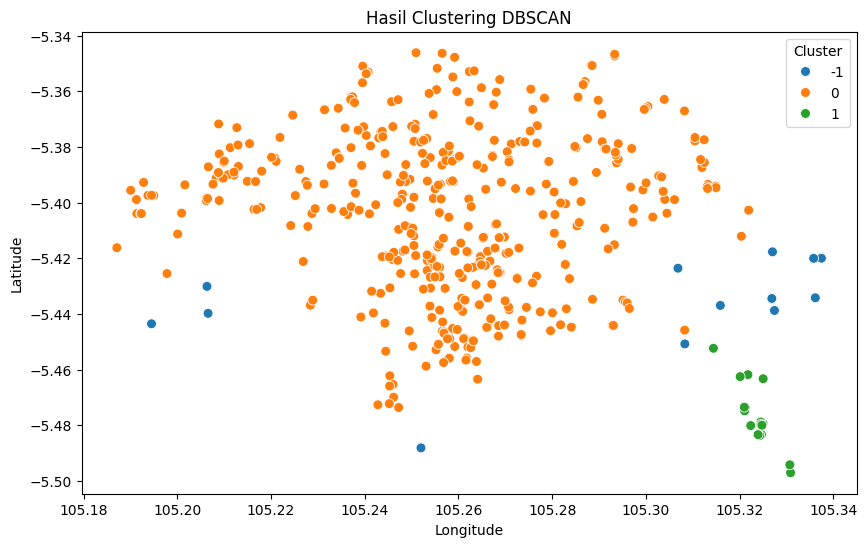

Silhouette Score: 0.5122
Davies–Bouldin Index: 0.4346
Jumlah cluster nyata (tidak termasuk noise): 2


In [76]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, davies_bouldin_score

dbscan = DBSCAN(eps=0.015, min_samples=6)
cluster_labels = dbscan.fit_predict(df[['Longitude', 'Latitude']])

df['Cluster'] = cluster_labels

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Cluster', palette='tab10', s=50)
plt.title('Hasil Clustering DBSCAN')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.show()

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_non_noise = sum(cluster_labels != -1)

if n_clusters > 1 and n_non_noise > 1:
    silhouette = silhouette_score(df[cluster_labels != -1][['Longitude', 'Latitude']],
                                   cluster_labels[cluster_labels != -1])
    db_index = davies_bouldin_score(df[cluster_labels != -1][['Longitude', 'Latitude']],
                                     cluster_labels[cluster_labels != -1])
    print(f'Silhouette Score: {silhouette:.4f}')
    print(f'Davies–Bouldin Index: {db_index:.4f}')
else:
    print('Evaluasi tidak dapat dilakukan karena jumlah cluster terlalu sedikit atau hanya noise.')

print(f'Jumlah cluster nyata (tidak termasuk noise): {n_clusters}')

Apa arti dari eps 0.015?

In [74]:
import math

df = pd.DataFrame(df_sekolah)

average_latitude = df["Latitude"].mean()

km_per_degree_longitude = 111.32 * math.cos(math.radians(average_latitude))

epsilon_degrees = 0.015
epsilon_km = km_per_degree_longitude * epsilon_degrees

average_latitude, km_per_degree_longitude, epsilon_km

(np.float64(-5.4078773626074215), 110.8245165308528, 1.662367747962792)

Nilai	Makna\
-5.407877	Rata-rata lintang lokasi (average_latitude)\
110.8245165	Panjang 1 derajat bujur pada lintang itu (dalam km)\
1.662367	Jarak dari 0.015 derajat bujur (epsilon) pada lintang itu (dalam km)\

Kesimpulannya : Di lintang sekitar -5.41°, pergeseran bujur sejauh 0.015° setara dengan ±1.66 km di permukaan bumi.

# **Visualisasi hasil clustering DBSCAN**

Gambar ini menunjukkan hasil klasterisasi sekolah di Kota Bandar Lampung berdasarkan koordinat geografis (longitude dan latitude) menggunakan algoritma DBSCAN.

- Titik warna oranye: Cluster 0 (sekolah mayoritas)
- Titik warna hijau: Cluster 1 (kelompok sekolah yang terpisah secara spasial)
- Titik warna biru: Noise (sekolah yang tidak memiliki cukup tetangga dalam radius epsilon)

Metrik evaluasi:
- Silhouette Score: 0.5122 ARTINYA cluster cukup baik secara pemisahan dan kekompakan
- Davies-Bouldin Index: 0.4346 ARTINYA cluster kompak dan tidak terlalu tumpang tindih


### Jumlah Cluster & Noise
Terdapat 2 cluster nyata yang terbentuk:
- **Cluster 0** mencakup mayoritas sekolah dan menggambarkan area dengan kepadatan normal hingga tinggi.
- **Cluster 1** terdiri dari sekolah-sekolah yang membentuk kelompok kecil di area tertentu (bagian timur Bandar Lampung), yang kemungkinan memiliki kepadatan spasial tinggi di lokal tersebut.
- **Noise (label -1)** terdiri dari sekolah-sekolah yang tidak cukup dekat dengan titik lain dalam radius epsilon, sehingga dianggap terisolasi.

Hal ini menunjukkan bahwa sebagian besar wilayah Kota Bandar Lampung memiliki distribusi sekolah yang cukup padat, dengan beberapa wilayah yang lebih terpencil.


Jumlah titik per cluster:
Cluster
-1     14
 0    476
 1     22
Name: count, dtype: int64


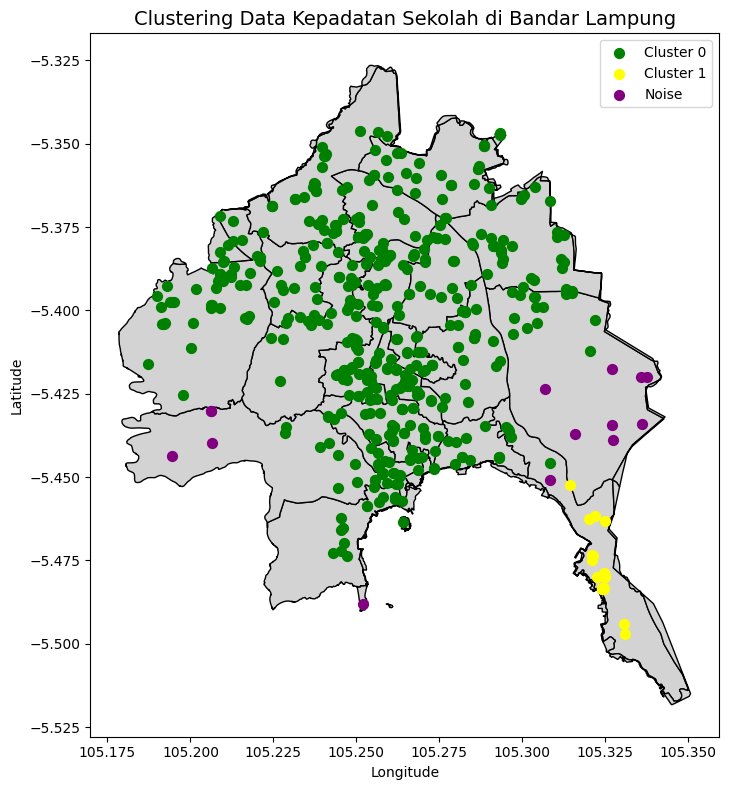

In [77]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

cluster_counts = df['Cluster'].value_counts().sort_index()
print("Jumlah titik per cluster:")
print(cluster_counts)

shapefile_path = '/content/gabungan_kecamatan_wilayah.shp'
gdf = gpd.read_file(shapefile_path)

from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
gdf_points = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326') 

cluster_colors = {
    0: 'green',
    1: 'yellow',
    -1: 'purple' 
}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(ax=ax, color='lightgray', edgecolor='black')

for cluster_id, color in cluster_colors.items():
    cluster_data = gdf_points[gdf_points['Cluster'] == cluster_id]
    cluster_data.plot(ax=ax, marker='o', color=color, markersize=50, label=f'Cluster {cluster_id}' if cluster_id != -1 else 'Noise')

plt.title("Clustering Data Kepadatan Sekolah di Bandar Lampung", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.tight_layout()
plt.show()


# **Visualisasi hasil DBSCAN pada peta Bandar Lampung (GADM)**

Hasil clustering diplot di atas peta wilayah administratif Kota Bandar Lampung untuk menunjukkan distribusi spasial dari masing-masing cluster:

- Cluster 0 (hijau): Terdistribusi hampir di seluruh wilayah
- Cluster 1 (kuning): Mengelompok di wilayah paling timur (kemungkinan wilayah sekolah-sekolah yang berdekatan tapi jauh dari pusat kota)
- Noise (ungu): Sekolah yang terisolasi secara spasial dan tidak memiliki cukup tetangga dekat

Visualisasi ini mendukung pemetaan geografis dan pemerataan fasilitas pendidikan berdasarkan sebaran spasial.


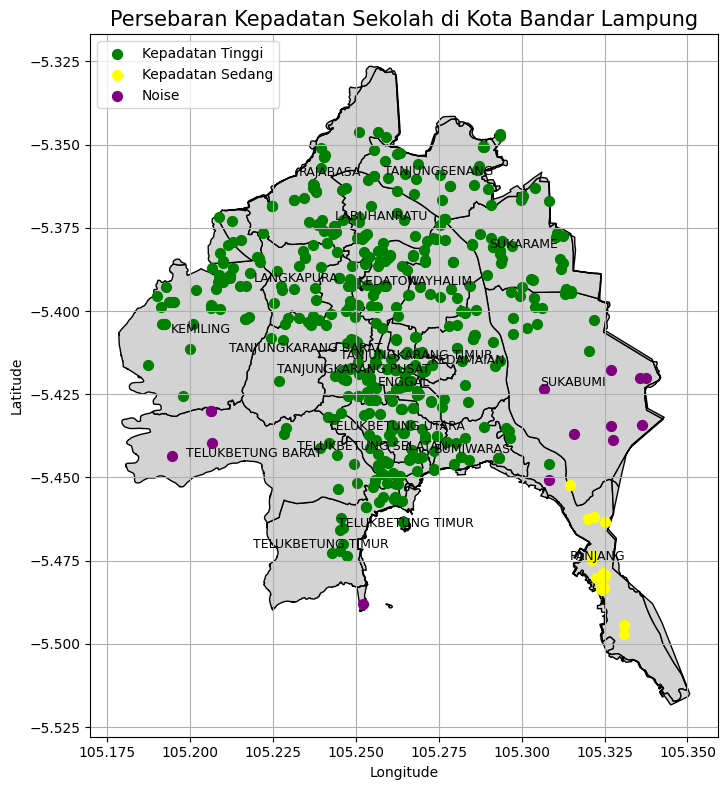

In [80]:
shapefile_path = '/content/gabungan_kecamatan_wilayah.shp'
gdf = gpd.read_file(shapefile_path)

from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]
gdf_points = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326') 

cluster_labels_map = {
    0: ('Kepadatan Tinggi', 'green'),
    1: ('Kepadatan Sedang', 'yellow'),
    -1: ('Noise', 'purple')
}

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(ax=ax, color='lightgray', edgecolor='black')

for cluster_id, (label, color) in cluster_labels_map.items():
    cluster_data = gdf_points[gdf_points['Cluster'] == cluster_id]
    cluster_data.plot(ax=ax, marker='o', color=color, markersize=50, label=label)

kecamatan_gdf = gpd.read_file("/content/Balam fix.shp")

wilayah_gdf = gpd.read_file("/content/Administrasi Kota Bandar Lampung-BIG.shp")
if kecamatan_gdf.crs != wilayah_gdf.crs:
    kecamatan_gdf = kecamatan_gdf.to_crs(wilayah_gdf.crs)

crs_asli = kecamatan_gdf.crs

kecamatan_utm = kecamatan_gdf.to_crs("EPSG:32748")
kecamatan_utm['centroid'] = kecamatan_utm.geometry.centroid

kecamatan_gdf['centroid'] = kecamatan_utm['centroid'].to_crs(crs_asli)

kecamatan_gdf['Longitude'] = kecamatan_gdf['centroid'].x
kecamatan_gdf['Latitude'] = kecamatan_gdf['centroid'].y

for _, row in kecamatan_gdf.iterrows():
    name = row['NAMOBJ']
    lon = row['Longitude']
    lat = row['Latitude']
    ax.text(
        lon, lat, name, fontsize=9, ha='center', va='center',
        bbox=dict(facecolor='none', edgecolor='none', alpha=0.6), zorder=3
    )

plt.title('Persebaran Kepadatan Sekolah di Kota Bandar Lampung', fontsize=15)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()